# LOT 2026 - Cognitive modeling meets computational linguistics (Yevgen Matusevych)
## Day 2 practical
## When does a language model stop being a good model of the reader?

**Question.** Does *more* (more training, more parameters) make a *better cognitive model*? We treat training as a variable we manipulate and consider the effect on the human reading times prediction.

**Models.** EleutherAI's **Pythia** suite is built for this: every size is trained on the same data in the same order, with 154 released checkpoints. We load the same model at different points in its training (`step1` … `step143000`).

**The code is mostly from Byung-Doh Oh, used as-is.** We clone [`byungdoh/llm_surprisal`](https://github.com/byungdoh/llm_surprisal) (Oh et al., 2024, EACL) and call its `get_llm_surprisal.py` (per-word surprisal, with article-level sliding-window context) and `get_unigram_surprisal.py` (a frequency baseline from Pile counts). Our own code only (a) builds the stimulus file, (b) loops the original scripts over checkpoints, and (c) fits the reading-time regression and creates plots.

**The method** also follows Oh & Schuler (2023, EMNLP): for each checkpoint, measure how much LM surprisal improves a regression of reading times over a baseline (i.e., the increase in log-likelihood) and plot it against training progress. Their result, which we try to reproduce: the fit *rises to a peak around two billion training tokens and then falls*, even as the model keeps becoming a better language model.

**Data:** Natural Stories reading times (Futrell et al. 2021), shipped as `natural_stories_words.csv`.

It's best to run this notebook on Google Colab (using a CPU is OK). The most time-consuming part is downloading: each checkpoint is a full set of weights.

## 0 · Setup — dependencies and Oh's codebase

In [ ]:
%pip install -q torch transformers numpy statsmodels pandas matplotlib

In [ ]:
import os
import sys
import io
import csv
import subprocess
import urllib.request

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Oh & Schuler's published surprisal code (EACL 2024). We run it unchanged; our
# own code only prepares its input and analyses its output.
REPO = "llm_surprisal"
REPO_URL = "https://github.com/byungdoh/llm_surprisal.git"
if not os.path.isdir(REPO):
    subprocess.run(
        ["git", "clone", "--quiet", "--branch", "eacl24", "--depth", "1", REPO_URL],
        check=True,
    )

# Pythia trains with a fixed batch of 2,097,152 tokens per step, so
# (training step) x (tokens per step) = number of tokens the model has seen.
TOKENS_PER_STEP = 2097152

print("Oh's scripts:", sorted(f for f in os.listdir(REPO) if f.endswith(".py")))


Oh's scripts: ['get_llm_surprisal.py', 'get_unigram_surprisal.py']


## 1. Human reading times → Oh's stimulus format

We load the by-word Natural Stories reading times and write them out in the `!ARTICLE`-delimited format Oh's
scripts expect. Two functions: one to fetch and tidy the data (only if it isn't already on disk), and one to
write the stimulus file. The word order is preserved throughout — that is what lets us merge the model's
by-word output back onto the reading times later.

In [ ]:
def download_natural_stories_rts(path):
    """Download and tidy the Natural Stories by-word reading times.

    Writes a CSV with columns [story, position, word, mean_rt_ms]: one row per
    word, ordered by (story, position). Only called if `path` does not exist.
    """
    url = ("https://raw.githubusercontent.com/languageMIT/naturalstories/"
           "master/naturalstories_RTS/processed_wordinfo.tsv")
    raw = urllib.request.urlopen(url).read().decode()

    rows = []
    for row in csv.DictReader(io.StringIO(raw), delimiter="\t"):
        try:
            rows.append((int(row["item"]), int(row["zone"]),
                         row["word"].strip(), round(float(row["meanItemRT"]), 2)))
        except (ValueError, TypeError):
            continue  # skip the occasional non-numeric / header artefact row

    rows.sort(key=lambda r: (r[0], r[1]))  # reading order: story, then position
    columns = ["story", "position", "word", "mean_rt_ms"]
    pd.DataFrame(rows, columns=columns).to_csv(path, index=False)


CSV_PATH = "natural_stories_words.csv"
if not os.path.exists(CSV_PATH):
    download_natural_stories_rts(CSV_PATH)

STORIES = [1, 2]   # subset of the 10 stories; add more for a less noisy estimate

# Keep only the chosen stories, in reading order. Everything downstream depends
# on this ordering, because we align the model's output to it by position.
rt = (pd.read_csv(CSV_PATH)
        .query("story in @STORIES")
        .sort_values(["story", "position"])
        .reset_index(drop=True))

# Low-level predictors a psycholinguist controls for *before* crediting surprisal
# with anything: word length and position in the story.
letters_only = rt["word"].str.replace(r"[^A-Za-z']", "", regex=True)
rt["length"] = letters_only.str.len().clip(lower=1)
rt["position_n"] = rt["position"]

print(f"{len(rt)} words across stories {STORIES}")
rt.head(3)


2063 words across stories [1, 2]


,story,position,word,mean_rt_ms,length,position_n
0,1,1,If,369.01,2,1
1,1,2,you,368.18,3,2
2,1,3,were,344.32,4,3


In [ ]:
def write_article_file(df, path):
    """Write the reading-time words in Oh's `!ARTICLE` stimulus format.

    Each story becomes one line of space-separated words, preceded by an
    `!ARTICLE` marker. The word order matches `df` exactly, which is what allows
    us to line up the script's by-word output with the reading times.
    """
    with open(path, "w") as f:
        for _, story_df in df.groupby("story"):
            words = story_df["word"].tolist()
            assert all(w and " " not in w for w in words), "words must be space-free"
            f.write("!ARTICLE\n")
            f.write(" ".join(words) + "\n")


STIMULUS = os.path.abspath("natural_stories.sentitems")
write_article_file(rt, STIMULUS)
print("wrote stimulus file:", STIMULUS)


wrote stimulus file: /content/natural_stories.sentitems


## 2. Wrappers around Oh's scripts

These functions just *call* the original command-line scripts and parse their two-column output. We run them with the
repo as the working directory because `get_unigram_surprisal.py` loads its count table by a relative path.

In [ ]:
def parse_surprisal_output(text):
    """Parse the two-column stdout of Oh's scripts into (word, value) pairs.

    The first line is a header ("word llmsurp" or "word unigramsurp"); each other
    line is "<word> <number>". Words never contain spaces, so we split on the
    last space.
    """
    pairs = []
    for line in text.splitlines()[1:]:      # [1:] drops the header line
        line = line.rstrip()
        if not line:
            continue
        word, value = line.rsplit(" ", 1)
        pairs.append((word, float(value)))
    return pairs


def run_script(script, *args):
    """Run one of Oh's scripts inside the repo and return its parsed output.

    Raises RuntimeError (with the script's stderr) if it exits non-zero.
    """
    result = subprocess.run(
        [sys.executable, script, *args],
        cwd=REPO, capture_output=True, text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(result.stderr[-2000:])
    return parse_surprisal_output(result.stdout)


def lm_word_surprisal(model, checkpoint=None):
    """By-word LM surprisal (in bits) for one model / checkpoint.

    `checkpoint` is a Pythia training step like "step1000"; omit it for models
    without checkpoints (e.g. "gpt2"). Oh's script handles tokenisation,
    article-level sliding-window context, and summing subwords back into words.
    """
    args = [STIMULUS, model] + ([checkpoint] if checkpoint else []) + ["word"]
    return run_script("get_llm_surprisal.py", *args)


def unigram_surprisal():
    """By-word unigram surprisal (in bits) from Pile counts — the frequency baseline."""
    return run_script("get_unigram_surprisal.py", STIMULUS, "word")


def attach_column(df, name, pairs):
    """Add a script's by-word output to `df` as a new column, aligned by order.

    Oh's output has one row per input word, in the same order as the stimulus, so
    we can assign by position. We compare the words first to catch any silent
    misalignment (which would invalidate the regression).
    """
    words = [word for word, _ in pairs]
    n = min(len(words), len(df))
    if words[:n] != df["word"].tolist()[:n]:
        raise ValueError("word mismatch between script output and reading-time data")
    values = [value for _, value in pairs]
    df[name] = values[:n] + [np.nan] * (len(df) - n)


### The frequency baseline (run once)

This is Oh's Pile-based unigram surprisal — the same frequency control the paper uses. The first call also
downloads the small Pythia tokenizer.

In [ ]:
attach_column(rt, "unigram_surp", unigram_surprisal())
print("baseline ready;", int(rt["unigram_surp"].notna().sum()), "words scored")


baseline ready; 2063 words scored


## 3. The fit measure

Recall the linking hypothesis (slide: *surprisal & reading times*): surprisal(w) = −log₂ P(w | context), in bits, and reading time rises roughly linearly with it (Smith & Levy 2013). The same model gives us a perplexity *and* these per-word surprisals.

The cognitive criterion (Oh & Schuler's): fit two regressions of reading time (a baseline; the baseline
plus LM surprisal) and report how much the log-likelihood improves. A larger increase means surprisal
explains human reading effort *over and above* frequency and length.

In [ ]:
def zscore(series):
    """Standardise to mean 0, sd 1 so regression terms are on a common scale."""
    sd = series.std()
    return (series - series.mean()) / (sd if sd else 1.0)


def reading_time_fit(df, surprisal_col):
    """Increase in regression log-likelihood from adding LM surprisal.

    baseline : reading time ~ length + position + unigram surprisal
    full     : baseline + LM surprisal
    Returns  : logLik(full) - logLik(baseline). Higher = better fit to humans.

    Note: this is a simplified version, OLS instead of a linear
    mixed-effects model (no by-subject/by-item random effects, no spillover).
    """
    predictors = ["length", "position_n", "unigram_surp", surprisal_col]
    data = df.dropna(subset=predictors + ["mean_rt_ms"]).copy()
    for col in predictors:
        data[col] = zscore(data[col])

    reading_time = data["mean_rt_ms"].values
    baseline = sm.add_constant(data[["length", "position_n", "unigram_surp"]])
    full = sm.add_constant(data[predictors])

    loglik_baseline = sm.OLS(reading_time, baseline).fit().llf
    loglik_full = sm.OLS(reading_time, full).fit().llf
    return loglik_full - loglik_baseline


## 4. The training axis: same model, different checkpoints (amount of training)

Hold the model fixed (`pythia-160m`) and vary only how long it trained. Oh & Schuler's prediction: fit to
reading times peaks near **2 billion tokens** (≈ **step 1000** for Pythia) and then declines. Each checkpoint
is a separate model download.

At 2,097,152 tokens/step, two billion tokens is step ≈ 954, which we round to step1000, the nearest checkpoint.


In [ ]:
MODEL = "EleutherAI/pythia-160m"
CHECKPOINTS = ["step1", "step128", "step512", "step1000",
               "step2000", "step8000", "step32000", "step143000"]

records = []
for checkpoint in CHECKPOINTS:
    attach_column(rt, "lm_surp", lm_word_surprisal(MODEL, checkpoint))
    step = int(checkpoint.removeprefix("step"))
    records.append({
        "checkpoint": checkpoint,
        "tokens": step * TOKENS_PER_STEP,
        "bits_per_word": rt["lm_surp"].mean(),            # lower = better language model
        "delta_loglik": reading_time_fit(rt, "lm_surp"),  # higher = better cognitive fit
    })
    last = records[-1]
    print(f"{checkpoint:>10}  bits/word={last['bits_per_word']:6.2f}  ΔLL={last['delta_loglik']:7.2f}")

trajectory = pd.DataFrame(records)


     step1  bits/word= 19.50  ΔLL=  12.81
   step128  bits/word= 12.35  ΔLL=   0.43
   step512  bits/word=  8.87  ΔLL=  14.13
  step1000  bits/word=  7.57  ΔLL=  37.16
  step2000  bits/word=  6.47  ΔLL=  34.37
  step8000  bits/word=  5.76  ΔLL=  39.69
 step32000  bits/word=  5.55  ΔLL=  32.92
step143000  bits/word=  5.54  ΔLL=  31.09


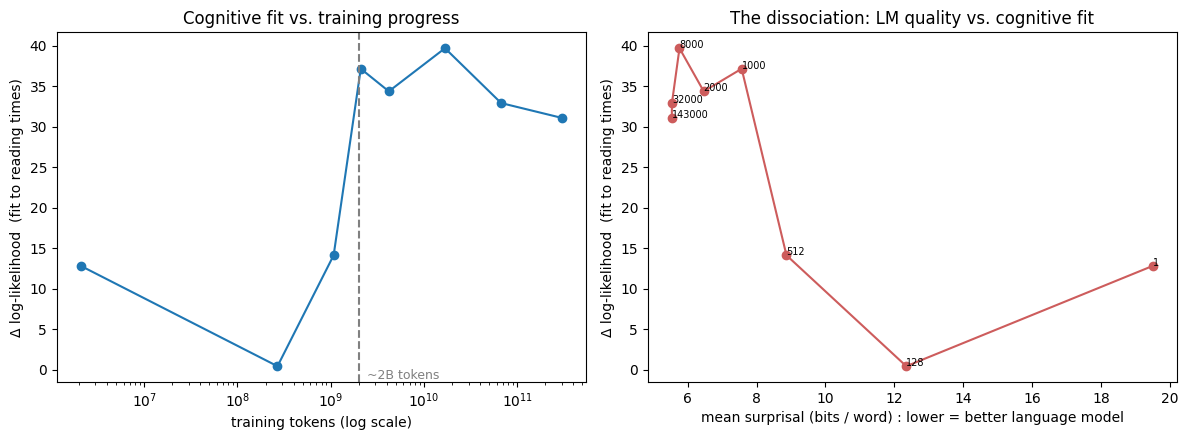

In [ ]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: cognitive fit as a function of how much the model has trained.
ax_left.plot(trajectory["tokens"], trajectory["delta_loglik"], "o-")
ax_left.set_xscale("log")
ax_left.set_xlabel("training tokens (log scale)")
ax_left.set_ylabel("Δ log-likelihood  (fit to reading times)")
ax_left.axvline(2e9, ls="--", color="grey")
ax_left.text(2e9, ax_left.get_ylim()[0], "  ~2B tokens", color="grey", va="bottom", fontsize=9)
ax_left.set_title("Cognitive fit vs. training progress")

# Right: the dissociation — better language model (left) need not mean better fit (up).
ax_right.plot(trajectory["bits_per_word"], trajectory["delta_loglik"], "o-", color="indianred")
for _, row in trajectory.iterrows():
    ax_right.annotate(row["checkpoint"].removeprefix("step"),
                      (row["bits_per_word"], row["delta_loglik"]), fontsize=7)
ax_right.set_xlabel("mean surprisal (bits / word) : lower = better language model")
ax_right.set_ylabel("Δ log-likelihood  (fit to reading times)")
ax_right.set_title("The dissociation: LM quality vs. cognitive fit")

plt.tight_layout()
plt.show()


**Read the left panel.** A rise to a peak near ~2B tokens followed by a decline reproduces the core result:
the model keeps getting *better at predicting text* yet becomes a *worse predictor of human reading*. The right
panel shows the dissociation directly. With a few hundred words the curve is wobbly; add stories to `STORIES`
to sharpen it.

*(`bits/word` is a monotone proxy for the model's quality here; true corpus perplexity comes from running the
scripts in `token` mode — a natural extension.)*

## 5. Why does the fit get worse? The frequency mechanism

The training-axis curve shows that an over-trained model fits worse, but not *why*. Oh & Schuler's (2024) answer
is **frequency**: as a model trains longer (or grows), its surprisal falls most for **rare** words — it learns
to predict them almost too well. Humans, though, keep slowing down on rare words. So the over-trained model's
surprisal *under-predicts the human slowdown exactly where it matters*, and that is where the reading-time fit
is lost.

We test this directly: contrast the early-peak checkpoint with the fully-trained one, bin words by frequency
(using the unigram baseline), and look at both the surprisals and the fit within each band.

In [ ]:
# Two contrasting checkpoints from the training sweep (cached, no new download):
#   the early peak (~2B tokens, best fit) vs. the fully-trained model (worse fit).
attach_column(rt, "surp_peak",        lm_word_surprisal(MODEL, "step1000"))
attach_column(rt, "surp_overtrained", lm_word_surprisal(MODEL, "step143000"))

# Split words into three frequency bands using the unigram baseline:
#   low unigram surprisal = frequent word, high = rare. We rank first so the
#   tercile boundaries are clean even when many words share a value.
rt["freq_band"] = pd.qcut(rt["unigram_surp"].rank(method="first"), 3,
                          labels=["frequent", "mid", "rare"])


def fit_by_band(df, surprisal_col):
    """Reading-time fit (ΔLL) computed separately within each frequency band."""
    return {band: reading_time_fit(group, surprisal_col)
            for band, group in df.groupby("freq_band", observed=True)}


peak_fit = fit_by_band(rt, "surp_peak")
over_fit = fit_by_band(rt, "surp_overtrained")

# Mean values per band in their natural units (no z-scoring): surprisal in bits,
# reading time in ms. We compare the two models' surprisal directly and report the
# human reading time alongside as the slowdown the model is meant to predict.
by_band = rt.groupby("freq_band", observed=True).agg(
    surp_peak=("surp_peak", "mean"),
    surp_overtrained=("surp_overtrained", "mean"),
    mean_rt_ms=("mean_rt_ms", "mean"),
).loc[["frequent", "mid", "rare"]]

print("Mean reading time rises on rarer words — the slowdown the model must predict:")
print(by_band["mean_rt_ms"].round(1).to_string(), "\n")
print("Reading-time fit (ΔLL) within each frequency band:")
for band in ["frequent", "mid", "rare"]:
    print(f"  {band:>9}:  peak={peak_fit[band]:6.2f}   over-trained={over_fit[band]:6.2f}")


Mean reading time rises on rarer words — the slowdown the model must predict:
freq_band
frequent    324.4
mid         330.3
rare        344.7 

Reading-time fit (ΔLL) within each frequency band:
   frequent:  peak=  5.54   over-trained=  5.91
        mid:  peak= 11.80   over-trained= 17.38
       rare:  peak= 15.44   over-trained=  9.58


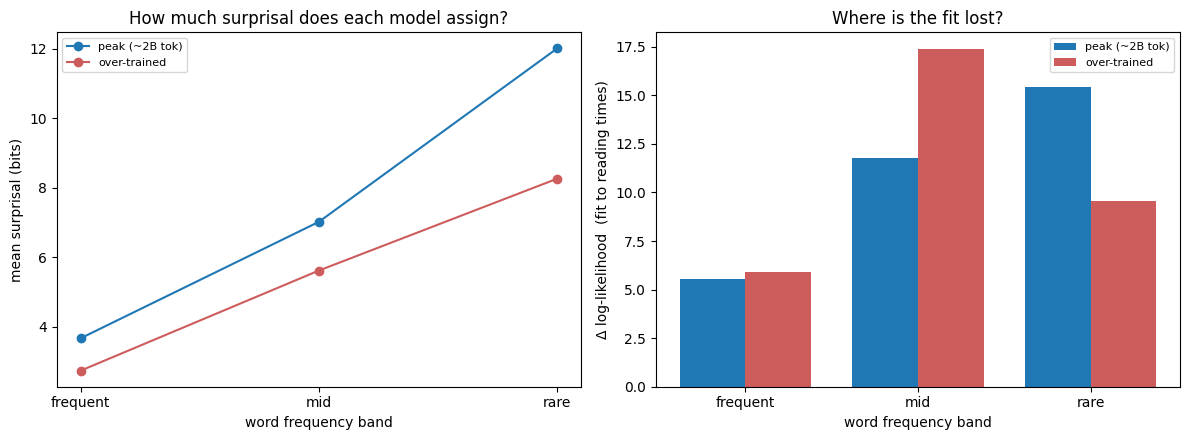

In [ ]:
fig, (ax_surp, ax_fit) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: each model's mean surprisal (bits) by band, in natural units. Both rise on
# rarer words, but the over-trained model is lower, and the gap to the peak model
# should be widest on rare words, where extra training has made it treat rare words
# as too predictable, supplying less of the surprisal those words need.
ax_surp.plot(by_band.index, by_band["surp_peak"], "o-", label="peak (~2B tok)")
ax_surp.plot(by_band.index, by_band["surp_overtrained"], "o-", color="indianred", label="over-trained")
ax_surp.set_xlabel("word frequency band")
ax_surp.set_ylabel("mean surprisal (bits)")
ax_surp.set_title("How much surprisal does each model assign?")
ax_surp.legend(fontsize=8)

# Right: where each model's reading-time fit actually lives.
bands = ["frequent", "mid", "rare"]
x = np.arange(len(bands))
width = 0.38
ax_fit.bar(x - width/2, [peak_fit[b] for b in bands], width, label="peak (~2B tok)")
ax_fit.bar(x + width/2, [over_fit[b] for b in bands], width, label="over-trained", color="indianred")
ax_fit.set_xticks(x)
ax_fit.set_xticklabels(bands)
ax_fit.set_xlabel("word frequency band")
ax_fit.set_ylabel("Δ log-likelihood  (fit to reading times)")
ax_fit.set_title("Where is the fit lost?")
ax_fit.legend(fontsize=8)

plt.tight_layout()
plt.show()


The plots show mean surprisal increasing from frequent to rare words — the human slowdown the model is meant to predict. On the **left**, both models assign more surprisal to rarer words, but the
over-trained model is lower, and the gap to the early-peak model should be widest on **rare** words: extra
training has taught it to treat rare words as more predictable, so it supplies *less* of the surprisal those
words need. On the **right**, that is exactly where the reading-time fit is lost — the over-trained model's
contribution shrinks (often toward zero) in the rare band while the early model still tracks the slowdown.
Frequency is the mechanism behind the inverted-U, which is the Oh & Schuler's (2024) central point, and the reason "a
better language model" and "a better model of the reader" come apart.

## 6. The size axis (optional) — same data, more parameters

Fix the fully-trained checkpoint and vary model **size**. Bigger Pythia models have lower surprisal; the
inverse-scaling claim is that their fit to reading times is no better, and often worse. (`pythia-410m` is ~900 MB.)

We plot the two metrics *against each other* rather than as side-by-side bars: language-model quality on the
x-axis (better is to the right), reading-time fit on the y-axis (up is better). The "ideal" corner
is top-right. The point of the plot is that the size trajectory does **not** head there: gaining
language-model quality drags the cognitive fit down.

    pythia-70m  bits/word=  6.29  ΔLL=  33.78
   pythia-160m  bits/word=  5.54  ΔLL=  31.09
   pythia-410m  bits/word=  4.89  ΔLL=  27.18


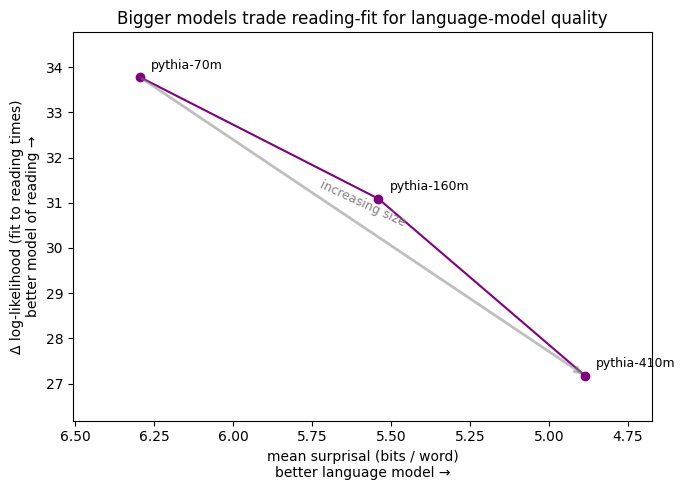

In [ ]:
RUN_SIZE_AXIS = True

if RUN_SIZE_AXIS:
    sizes = ["EleutherAI/pythia-70m", "EleutherAI/pythia-160m", "EleutherAI/pythia-410m"]
    size_records = []
    for model in sizes:
        attach_column(rt, "lm_surp", lm_word_surprisal(model, "step143000"))
        size_records.append({
            "model": model.split("/")[-1],
            "bits_per_word": rt["lm_surp"].mean(),
            "delta_loglik": reading_time_fit(rt, "lm_surp"),
        })
        last = size_records[-1]
        print(f"{last['model']:>14}  bits/word={last['bits_per_word']:6.2f}  ΔLL={last['delta_loglik']:7.2f}")

    size_df = pd.DataFrame(size_records)

    # One plot, not two: LM quality on x, cognitive fit on y, sizes connected in
    # order. The dissociation is the shape of the line, and both axes are oriented
    # so that "better" points the same way (up / right) -- we invert x so that
    # lower surprisal (a better LM) sits on the right.
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(size_df["bits_per_word"], size_df["delta_loglik"], "o-", color="purple", zorder=2)
    for _, row in size_df.iterrows():
        ax.annotate(row["model"], (row["bits_per_word"], row["delta_loglik"]),
                    textcoords="offset points", xytext=(8, 6), fontsize=9)

    # arrow marking the direction of increasing model size
    first, last = size_df.iloc[0], size_df.iloc[-1]
    ax.annotate("", xy=(last["bits_per_word"], last["delta_loglik"]),
                xytext=(first["bits_per_word"], first["delta_loglik"]),
                arrowprops=dict(arrowstyle="->", color="grey", lw=2, alpha=0.5))
    ax.text(0.5, 0.5, "increasing size", transform=ax.transAxes,
            color="grey", fontsize=9, rotation=-25, ha="center")

    ax.invert_xaxis()  # better language model -> to the right
    ax.margins(0.15)
    ax.set_xlabel("mean surprisal (bits / word)\nbetter language model \u2192")
    ax.set_ylabel("\u0394 log-likelihood (fit to reading times)\nbetter model of reading \u2192")
    ax.set_title("Bigger models trade reading-fit for language-model quality")
    plt.tight_layout()
    plt.show()


## 7. Wrap-up

You used a checkpoint 'slider' as a scientific instrument: holding data and architecture fixed, moving only
training amount (then only size), and reading the consequence off one cognitive measure, with all surprisal
computed by the original authors' code.

- **Trajectory, not endpoint.** The fully trained model is not the best model of the reader; the best one appears
  early in training (~2B tokens). You only see this by looking at the trajectory.
- **Quality ≠ cognitive fit.** Lower surprisal is associated with *worse* reading-time fit.

**Extensions**
- Run the scripts in `token` mode for true perplexity; compare Pythia vs **Pythia-deduped** to isolate a data change.
- Swap reading times for **BLiMP** across the same checkpoints — grammatical competence on the same timeline.

*Surprisal & unigram baseline: Byung-Doh Oh's `llm_surprisal` (EACL 2024). Models: Pythia (Biderman et al. 2023). Method after Oh & Schuler (2023). Data: Natural Stories (Futrell et al. 2021), CC BY-NC-SA.*
